<a href="https://colab.research.google.com/github/AmanGupta3995377/Celebal-Week3-Assignment/blob/main/week3_aman_gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 Assignment - Customer Intelligence System

## Topics Covered

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Scaling
- K-Means Clustering
- DBSCAN Clustering
- Cluster Visualization
- Logistic Regression
- Random Forest
- Confusion Matrix
- Feature Importance
- Model Comparison
- Classification Metrics
- Unsupervised Learning

# Loading Dataset

In [2]:
import pandas as pd

df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

# Exploratory Data Analysis (EDA)

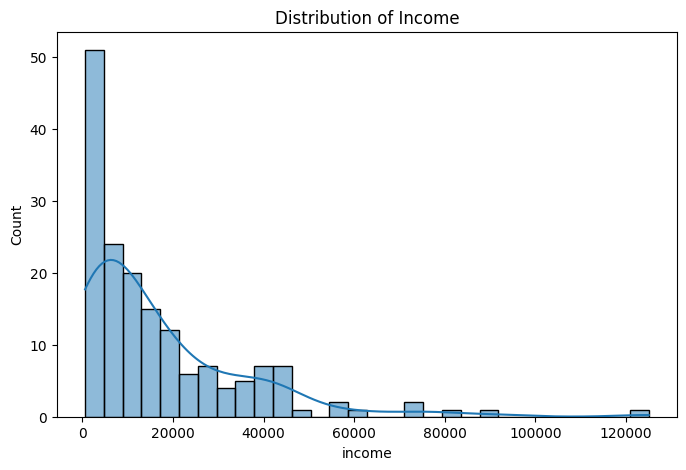

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['income'], bins=30, kde=True)

plt.title("Distribution of Income")
plt.show()

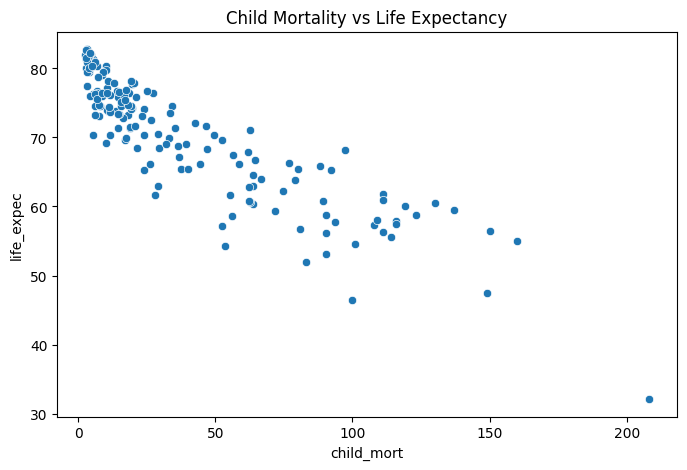

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='child_mort',
    y='life_expec',
    data=df
)

plt.title("Child Mortality vs Life Expectancy")
plt.show()

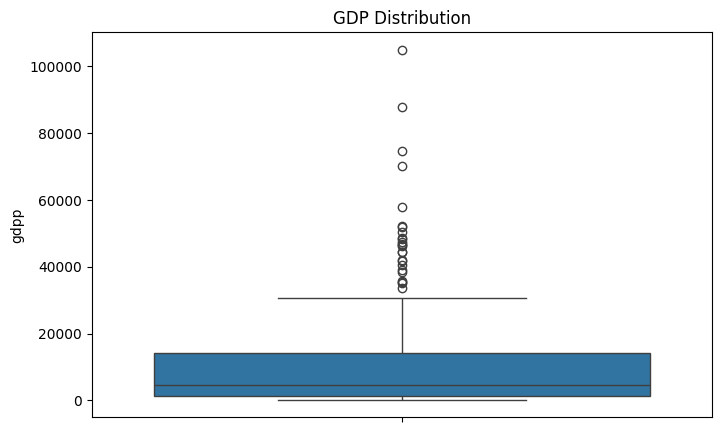

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df['gdpp'])

plt.title("GDP Distribution")
plt.show()

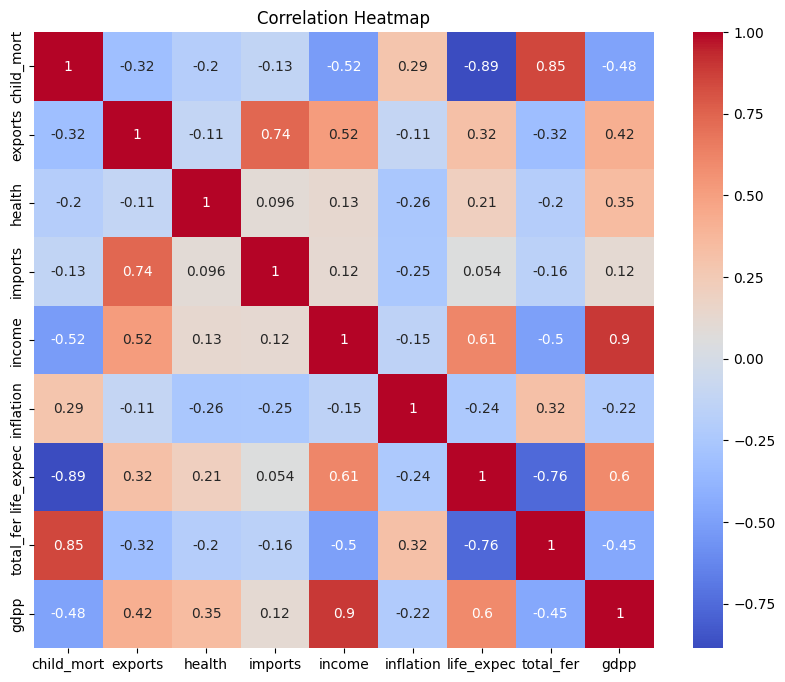

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Feature Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)

# Scaling data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.29153238 -1.13827979  0.27908825 -0.08245496 -0.8082454   0.15733622
  -1.61909203  1.90288227 -0.67917961]
 [-0.5389489  -0.47965843 -0.09701618  0.07083669 -0.3753689  -0.31234747
   0.64786643 -0.85997281 -0.48562324]
 [-0.27283273 -0.09912164 -0.96607302 -0.64176233 -0.22084447  0.78927429
   0.67042323 -0.0384044  -0.46537561]
 [ 2.00780766  0.77538117 -1.44807093 -0.16531531 -0.58504345  1.38705353
  -1.17923442  2.12815103 -0.51626829]
 [-0.69563412  0.1606679  -0.28689415  0.4975675   0.10173177 -0.60174853
   0.70425843 -0.54194633 -0.04181713]]


# K-Means Clustering

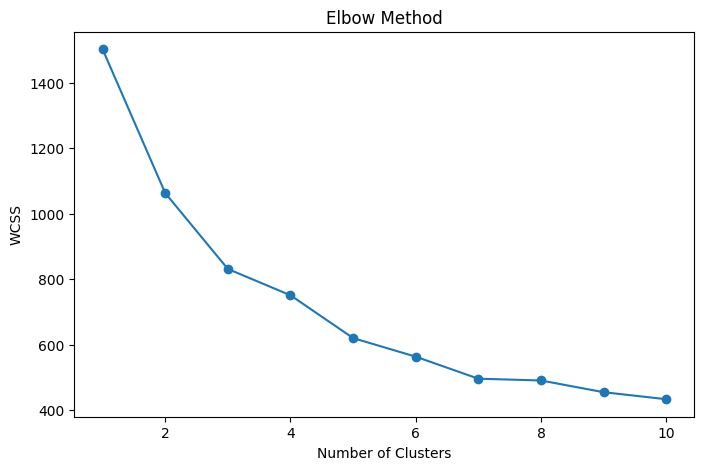

In [13]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# Applying K-Means Clustering

In [14]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# Adding cluster labels to dataframe
df['Cluster'] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


# Cluster Visualization

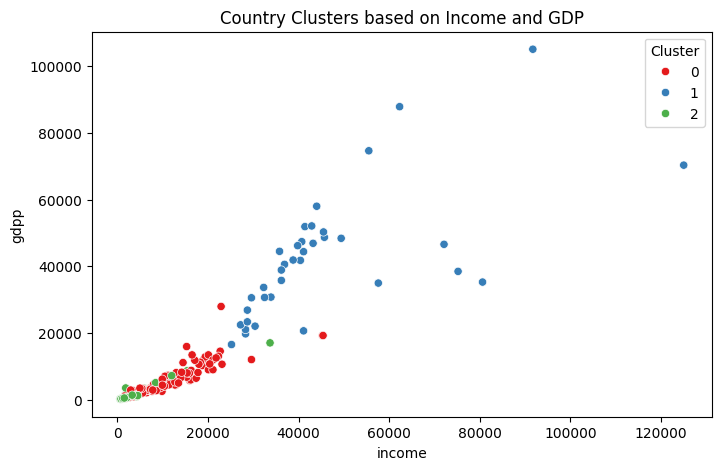

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['income'],
    y=df['gdpp'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Country Clusters based on Income and GDP")

plt.show()

# Data Preparation for Classification

In [16]:
# Features
X = df.drop(['country', 'Cluster'], axis=1)

# Target
y = df['Cluster']

print(X.shape)
print(y.shape)

(167, 9)
(167,)


# Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


# Feature Scaling for Classification

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# Confusion Matrix

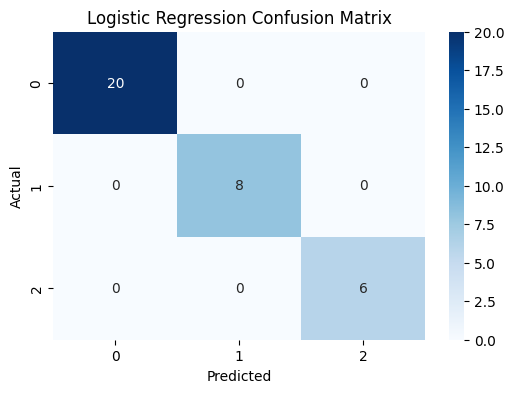

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Classifier

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



# Random Forest Confusion Matrix

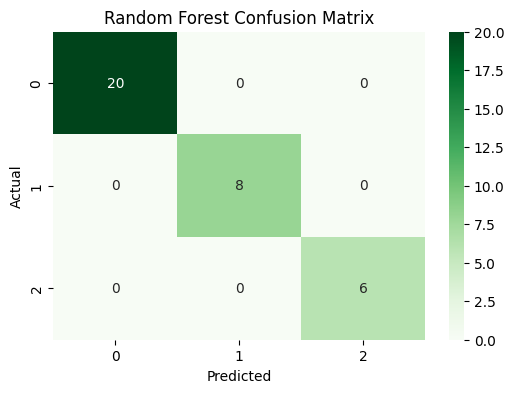

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Feature Importance

In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

      Feature  Importance
0  child_mort    0.293845
8        gdpp    0.210125
4      income    0.177148
7   total_fer    0.142312
6  life_expec    0.122588
2      health    0.019921
1     exports    0.014917
5   inflation    0.011745
3     imports    0.007400


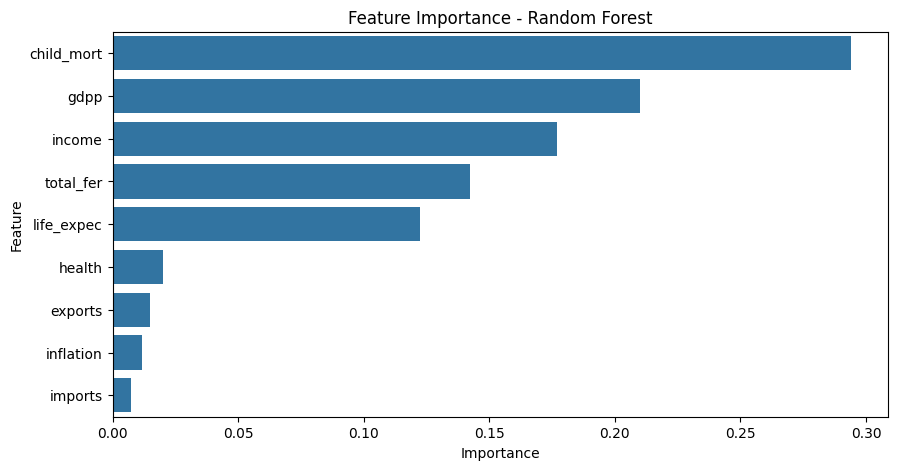

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")

plt.show()

# DBSCAN Clustering

In [25]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


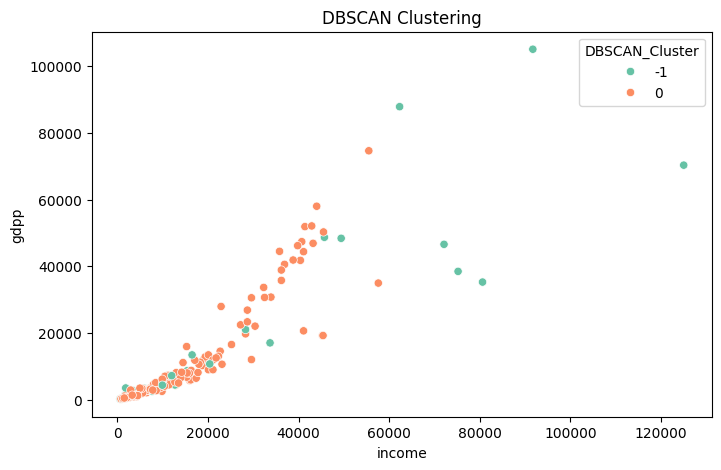

In [26]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['income'],
    y=df['gdpp'],
    hue=df['DBSCAN_Cluster'],
    palette='Set2'
)

plt.title("DBSCAN Clustering")

plt.show()

# Model Comparison

In [27]:
log_acc = accuracy_score(y_test, y_pred_log)

rf_acc = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_acc, rf_acc]
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression       1.0
1        Random Forest       1.0


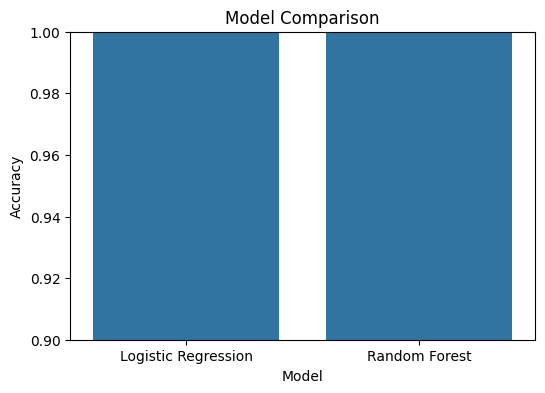

In [28]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Comparison")

plt.ylim(0.9, 1.0)

plt.show()

# Conclusion

In this project, I developed a Customer Intelligence System using classification, ensemble learning, and clustering techniques. I first performed Exploratory Data Analysis (EDA) to better understand the socio-economic and health-related factors affecting different countries.

K-Means and DBSCAN clustering were used to group countries based on their development patterns. I also implemented Logistic Regression and Random Forest models to classify country clusters with very high accuracy. Through feature importance analysis, factors such as child mortality, GDP, income, and life expectancy were identified as the most influential indicators.

Overall, this project demonstrated how machine learning techniques can be used to analyze country data, identify patterns, and classify countries based on socio-economic and health-related factors. It also helped in understanding how clustering and classification models can be applied to real-world datasets for data-driven analysis and decision-making.